# 01. ETH staking yield와 ETH-BTC funding spread
가설1/2 검정

In [1]:
import sys
from pathlib import Path


def resolve_project_root(start: Path) -> Path:
    """Find project root containing `common` and `data` directories."""
    for candidate in [start, *start.parents]:
        if (candidate / "common").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not resolve project root from current working directory")


PROJECT_ROOT = resolve_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT={PROJECT_ROOT}")

PROJECT_ROOT=C:\Users\nahom\jolup\jolup


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import stats

from common.transforms import funding_to_daily_annualized, build_spread, log_return
from common.stats import ols_hac
from common.visualization import plot_timeseries

In [3]:
RAW = PROJECT_ROOT / 'data' / 'raw'
PROCESSED = PROJECT_ROOT / 'data' / 'processed'

# funding 파일: 신규(perp panel) 포맷 우선, 구 포맷 fallback
eth_f_path = next((p for p in [
    RAW / 'binance_funding_ETHUSDT.csv',
    RAW / 'bybit_funding_ETHUSDT.csv',
    RAW / 'binance_ethusdt_funding.csv',
    RAW / 'bybit_ethusdt_funding.csv',
] if p.exists()), None)
btc_f_path = next((p for p in [
    RAW / 'binance_funding_BTCUSDT.csv',
    RAW / 'bybit_funding_BTCUSDT.csv',
    RAW / 'binance_btcusdt_funding.csv',
    RAW / 'bybit_btcusdt_funding.csv',
] if p.exists()), None)

assert eth_f_path and btc_f_path, 'funding 파일이 없습니다. scripts/collect_perp_funding_panel.py 먼저 실행하세요.'

eth_f = pd.read_csv(eth_f_path)
btc_f = pd.read_csv(btc_f_path)

# 가격 파일: 신규(perp panel) 포맷 우선, 구 포맷 fallback
eth_p_path = next((p for p in [RAW / 'binance_klines_ETHUSDT_1d.csv', RAW / 'binance_ethusdt_1d.csv'] if p.exists()), None)
btc_p_path = next((p for p in [RAW / 'binance_klines_BTCUSDT_1d.csv', RAW / 'binance_btcusdt_1d.csv'] if p.exists()), None)
assert eth_p_path and btc_p_path, '1d 가격 파일이 없습니다. scripts/collect_perp_funding_panel.py 먼저 실행하세요.'
eth_p = pd.read_csv(eth_p_path)
btc_p = pd.read_csv(btc_p_path)

# staking yield 패널(권장): build_eth_yield_panel 출력 우선
st_path = next((p for p in [
    PROCESSED / 'eth_yield_panel.csv',
    PROCESSED / 'lido_wsteth_share_rate.csv',
    RAW / 'eth_staking_yield_daily.csv',
] if p.exists()), None)
assert st_path is not None, 'eth_yield_panel.csv 또는 lido_wsteth_share_rate.csv 또는 eth_staking_yield_daily.csv 가 필요합니다.'
st = pd.read_csv(st_path)

In [4]:
# 1) funding -> daily annualized
eth_fd = funding_to_daily_annualized(eth_f, time_col='fundingTime', rate_col='fundingRate')
btc_fd = funding_to_daily_annualized(btc_f, time_col='fundingTime', rate_col='fundingRate')

# 2) spread 생성
spread = build_spread(eth_fd, btc_fd, value_col='funding_ann', out_col='spread')


def normalize_daily_date(series: pd.Series) -> pd.Series:
    """Normalize mixed date/timestamp inputs to naive daily datetime."""
    return pd.to_datetime(series, utc=True, errors='coerce').dt.tz_convert(None).dt.normalize()


# 3) 가격 수익률 생성
for px in (eth_p, btc_p):
    px['date'] = normalize_daily_date(px['date'])
eth_p['ret_eth'] = log_return(eth_p['close'])
btc_p['ret_btc'] = log_return(btc_p['close'])
ret = eth_p[['date', 'ret_eth']].merge(btc_p[['date', 'ret_btc']], on='date', how='inner')
ret['ret_eth_btc'] = ret['ret_eth'] - ret['ret_btc']

# 단순 RV proxy (절대수익률)
ret['rv_eth_btc'] = (ret['ret_eth'].abs() - ret['ret_btc'].abs())

# staking
st['date'] = normalize_daily_date(st['date'])
st['stake_yield'] = pd.to_numeric(st['stake_yield'], errors='coerce')
# stake_yield가 % 값이면 100으로 나누기 (예: 3.5 -> 0.035)
if st['stake_yield'].dropna().median() > 1:
    st['stake_yield'] = st['stake_yield'] / 100.0

spread['date'] = normalize_daily_date(spread['date'])
df = spread[['date', 'spread']].merge(ret[['date', 'ret_eth_btc', 'rv_eth_btc']], on='date', how='inner').merge(st[['date', 'stake_yield']], on='date', how='inner').dropna().sort_values('date').reset_index(drop=True)

df.head(), df.describe().T[['mean', 'std', 'min', 'max']]

(        date    spread  ret_eth_btc  rv_eth_btc  stake_yield
 0 2023-11-28  0.000000    -0.005275   -0.005275     0.035101
 1 2023-11-29  0.000000    -0.010370    0.009048     0.036662
 2 2023-11-30  0.000000     0.014630    0.008261     0.039998
 3 2023-12-01  0.000000    -0.007675   -0.007675     0.038645
 4 2023-12-02  0.016556     0.016979    0.016979     0.038888,
                             mean       std                  min  \
 date         2025-02-16 12:00:00       NaN  2023-11-28 00:00:00   
 spread                  0.003131  0.042091            -0.231359   
 ret_eth_btc            -0.000713  0.021406            -0.070008   
 rv_eth_btc              0.007419  0.018373            -0.048249   
 stake_yield             0.029494  0.005933             0.022821   
 
                              max  
 date         2026-05-09 00:00:00  
 spread                  0.219756  
 ret_eth_btc             0.135672  
 rv_eth_btc              0.135672  
 stake_yield             0.117656  )

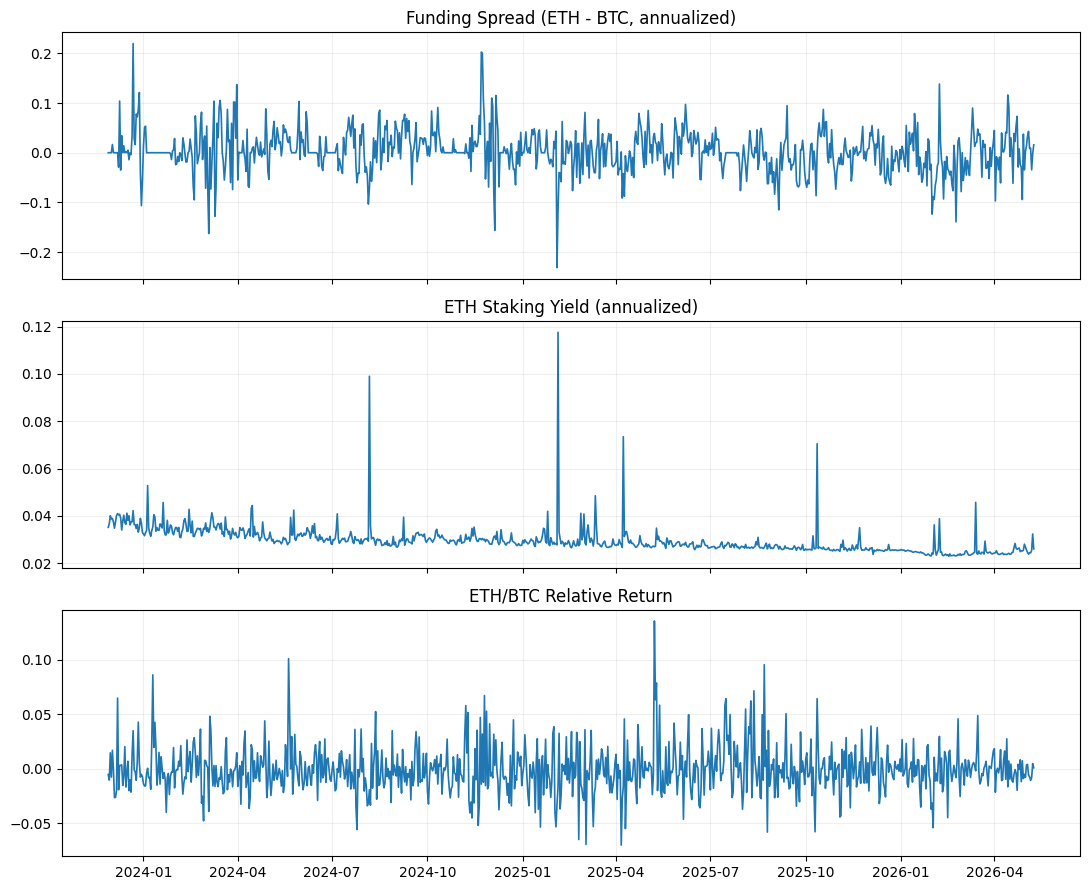

In [5]:
# 기초 시계열 시각화
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
plot_timeseries(df, 'date', 'spread', 'Funding Spread (ETH - BTC, annualized)', ax=axes[0])
plot_timeseries(df, 'date', 'stake_yield', 'ETH Staking Yield (annualized)', ax=axes[1])
plot_timeseries(df, 'date', 'ret_eth_btc', 'ETH/BTC Relative Return', ax=axes[2])
plt.tight_layout()

In [6]:
# 상관관계
corr = df[['spread', 'stake_yield', 'ret_eth_btc', 'rv_eth_btc']].corr()
corr

,spread,stake_yield,ret_eth_btc,rv_eth_btc
spread,1.000000,0.001049,0.124223,-0.009074
stake_yield,0.001049,1.000000,-0.000530,-0.077134
ret_eth_btc,0.124223,-0.000530,1.000000,0.254018
rv_eth_btc,-0.009074,-0.077134,0.254018,1.000000


In [7]:
# 가설1: 기본 회귀 spread ~ stake_yield
res1 = ols_hac(df['spread'], df[['stake_yield']], maxlags=5)
print(res1.summary())

                            OLS Regression Results                            
Dep. Variable:                 spread   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                 0.0002937
Date:                Sat, 09 May 2026   Prob (F-statistic):              0.986
Time:                        15:00:45   Log-Likelihood:                 1564.1
No. Observations:                 894   AIC:                            -3124.
Df Residuals:                     892   BIC:                            -3115.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0029      0.013      0.230      

In [8]:
# 가설2: 통제회귀 spread ~ stake_yield + ret_eth_btc + rv_eth_btc
res2 = ols_hac(df['spread'], df[['stake_yield', 'ret_eth_btc', 'rv_eth_btc']], maxlags=5)
print(res2.summary())

                            OLS Regression Results                            
Dep. Variable:                 spread   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     5.479
Date:                Sat, 09 May 2026   Prob (F-statistic):           0.000986
Time:                        15:01:07   Log-Likelihood:                 1571.8
No. Observations:                 894   AIC:                            -3136.
Df Residuals:                     890   BIC:                            -3116.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0045      0.012      0.374      

In [ ]:
# High/Low staking yield 그룹 평균 차이 t-test
median_y = df['stake_yield'].median()
high = df.loc[df['stake_yield'] > median_y, 'spread']
low = df.loc[df['stake_yield'] <= median_y, 'spread']
t_stat, p_val = stats.ttest_ind(high, low, equal_var=False, nan_policy='omit')
print({'high_mean': high.mean(), 'low_mean': low.mean(), 'diff': high.mean() - low.mean(), 't': t_stat, 'p': p_val})

## Hypothesis tests: ETF, alt-yield, queue

This section consumes the standardized outputs from `scripts/analyze_eth_btc_funding_staking.py` and provides:

- event/break summaries for a user-supplied candidate date list,
- rolling/MA flip-point visualization, and
- hypothesis-level key coefficient and significance summaries.


In [ ]:
# Hypothesis pipeline controls
import subprocess

EVENT_DATES = ["2024-07-23", "2025-07-01"]  # edit freely, e.g. ETH ETF launch and 2025-H2 break candidate
EXCHANGES = ["binance"]
HYPOTHESIS_MODE = "all"
FLIP_MIN_RUN = 20
RESULTS = PROJECT_ROOT / "data" / "results"
FIGURES = PROJECT_ROOT / "figures"

cmd = [
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "analyze_eth_btc_funding_staking.py"),
    "--exchanges", *EXCHANGES,
    "--hypothesis-mode", HYPOTHESIS_MODE,
    "--break-dates", *EVENT_DATES,
    "--flip-min-run", str(FLIP_MIN_RUN),
]
print(" ".join(map(str, cmd)))
# Uncomment to regenerate the CSV outputs from inside the notebook.
# subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)


In [ ]:
# Event/break summary table
break_tables = []
for exchange in EXCHANGES:
    path = RESULTS / f"{exchange}_hypothesis_event_breaks.csv"
    if path.exists():
        table = pd.read_csv(path)
        break_tables.append(table)
    else:
        print(f"Missing {path}; run the command cell above first.")

break_summary = pd.concat(break_tables, ignore_index=True) if break_tables else pd.DataFrame()
if not break_summary.empty:
    display_cols = [c for c in [
        "exchange", "test_type", "break_date", "period", "nobs",
        "stake_yield_coef", "stake_yield_pvalue", "interaction_coef",
        "wald_pvalue", "f_stat", "pvalue", "status", "reason",
    ] if c in break_summary.columns]
    display(break_summary[display_cols])
else:
    display(break_summary)


In [ ]:
# Rolling/MA flip point plot
fig, ax = plt.subplots(figsize=(11, 5))
for exchange in EXCHANGES:
    # The script saves the canonical PNG as well; this cell reconstructs a compact marker view from the CSV.
    path = RESULTS / f"{exchange}_hypothesis_rolling_flip_points.csv"
    if not path.exists():
        print(f"Missing {path}; run the hypothesis pipeline first.")
        continue
    flips = pd.read_csv(path)
    display(flips)
    for _, row in flips.dropna(subset=["first_positive_run_end_date"]).iterrows():
        ax.axvline(pd.to_datetime(row["first_positive_run_end_date"]), label=f"{exchange} {int(row['window'])}d flip")

ax.set_title("First sustained positive rolling stake_yield coefficient run")
ax.set_xlabel("Flip date")
ax.set_yticks([])
ax.legend(loc="best")
plt.show()


In [ ]:
# Hypothesis-level key coefficient/significance summary
summary_path = RESULTS / "hypothesis_master_summary.csv"
if summary_path.exists():
    hypothesis_summary = pd.read_csv(summary_path)
    display_cols = [c for c in [
        "exchange", "hypothesis", "best_interaction_model", "best_interaction_term",
        "best_interaction_coef", "best_interaction_pvalue", "min_break_wald_pvalue",
        "rolling_flip_dates", "decision_flag", "caution",
    ] if c in hypothesis_summary.columns]
    display(hypothesis_summary[display_cols])
else:
    print(f"Missing {summary_path}; run the hypothesis pipeline first.")
